<a href="https://colab.research.google.com/github/tamannagupta10/spam-detection/blob/main/Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

urllib.request.urlretrieve(url, "sms_spam_collection.zip")

with zipfile.ZipFile("sms_spam_collection.zip", "r") as zip_ref:
    zip_ref.extractall(".")

print("Dataset downloaded successfully!")


Dataset downloaded successfully!


In [3]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print("Dataset shape:", df.shape)

print("\nLabels:")
print(df["label"].value_counts())

Dataset shape: (5572, 2)

Labels:
label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [20]:
X = df["message"]
y = df["label_num"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [8]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (4457, 5000)
Testing matrix shape: (1115, 5000)


In [9]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.9721973094170404
Accuracy percentage: 97.21973094170404


In [12]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



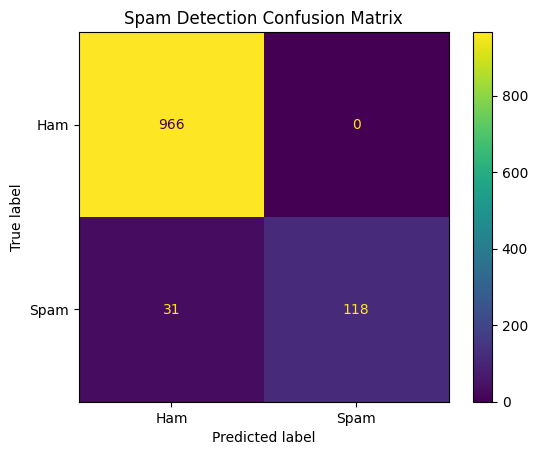

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Spam Detection Confusion Matrix")
plt.show()

In [14]:
def predict_spam(message):
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "NOT SPAM"

In [15]:
message = "Congratulations! You have won a free prize. Call now!"
print(predict_spam(message))

SPAM


In [16]:
message = "Hey, are we meeting at 6 pm today?"
print(predict_spam(message))

NOT SPAM


In [17]:
def predict_spam_with_probability(message):
    message_tfidf = vectorizer.transform([message])

    prediction = model.predict(message_tfidf)[0]
    probabilities = model.predict_proba(message_tfidf)[0]

    spam_probability = probabilities[1] * 100

    if prediction == 1:
        result = "SPAM"
    else:
        result = "NOT SPAM"

    print("Message:", message)
    print("Prediction:", result)
    print(f"Spam Probability: {spam_probability:.2f}%")

In [18]:
predict_spam_with_probability(
    "URGENT! You have won a free lottery prize. Claim now!"
)

Message: URGENT! You have won a free lottery prize. Claim now!
Prediction: SPAM
Spam Probability: 97.25%
